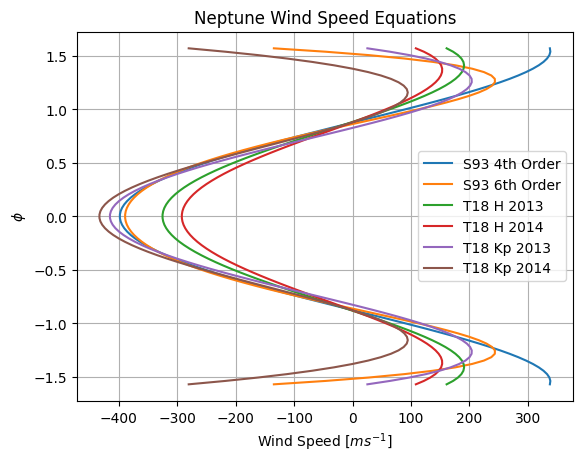

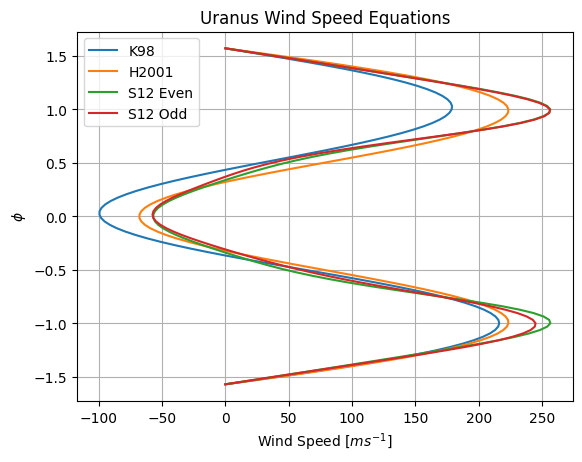

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from frequency_analysis.wind_equations import *

phi = np.linspace(-np.pi/2, np.pi/2, 100)

sromovsky1993_four = six_order_fit(-398, 1.88e-1, -1.2e-5)
sromovsky1993_six = six_order_fit(-389, 1.53e-1, 1.01e-5, -3.1e-9)

tollefson2013_h = six_order_fit(-325, 1.58e-1, -1.21e-5)
tollefson2013_kp = six_order_fit(-415, 2.35e-1, -2.23e-5)
tollefson2014_h = six_order_fit(-292, 1.45e-1, -1.18e-5)
tollefson2014_kp = six_order_fit(-433, 2.4e-1, -2.73e-5)

plt.plot(sromovsky1993_four(phi), phi, label="S93 4th Order")
plt.plot(sromovsky1993_six(phi), phi, label="S93 6th Order")

plt.plot(tollefson2013_h(phi), phi, label="T18 H 2013")
plt.plot(tollefson2014_h(phi), phi, label="T18 H 2014")
plt.plot(tollefson2013_kp(phi), phi, label="T18 Kp 2013")
plt.plot(tollefson2014_kp(phi), phi, label="T18 Kp 2014")
plt.title("Neptune Wind Speed Equations")
plt.xlabel(r"Wind Speed $[ms^{-1}]$")
plt.ylabel(r"$\phi$")
plt.grid()
plt.legend()
plt.show()

plt.plot(karkoshka1998(phi), phi, label="K98")
plt.plot(hammel2001(phi), phi, label="H2001")
plt.plot(sromovsky2012_even(phi), phi, label="S12 Even")
plt.plot(sromovsky2012_odd(phi), phi, label="S12 Odd")
plt.title("Uranus Wind Speed Equations")
plt.xlabel(r"Wind Speed $[ms^{-1}]$")
plt.ylabel(r"$\phi$")
plt.grid()
plt.legend()
plt.show()


In [8]:
from frequency_analysis.mcmc import *

phi = np.linspace(-np.pi/2, np.pi/2, 100)

uranus_min_freq = find_minimum_frequency(sromovsky1993_four, frequency_wind_speed(24764000, 24/1.5032))
neptune_min_freq = find_minimum_frequency(sromovsky2012_odd, frequency_wind_speed(25559000, 17.247864))

Minimum f with at least one intersection: 1.282201
Minimum f with at least one intersection: 1.360531


/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


In [3]:
times, flux = np.loadtxt('/scratch11/ktp9/TESS_SolarSystem/Neptune/s70_cam1_ccd1/results_bps40_pps10/lc_Neptune_s70_cam1_ccd1.txt')
print(times[0], times[-1])

2460208.360777491 2460233.8230893197


In [4]:
def load_npz(path, name):
    data = np.load(path + f"{name}_stack.npz")
    frequency_dt = data["frequency"]
    power_dt = data["power"]
    false_alarm_dt = data["false_alarm"]
    flux_detrended = data["flux"]
    peak_frequencies_dt = data["peak_freqs"]

    return data, frequency_dt, power_dt, false_alarm_dt, flux_detrended, peak_frequencies_dt

In [5]:
path = "/scratch11/ktp9/TESS_SolarSystem/"

u42_data, u42_frequency_dt, u42_power_dt, u42_false_alarm_dt, u42_flux_detrended, u42_peak_frequencies_dt = load_npz(path, "u42")
u43_data, u43_frequency_dt, u43_power_dt, u43_false_alarm_dt, u43_flux_detrended, u43_peak_frequencies_dt = load_npz(path, "u43")
u44_data, u44_frequency_dt, u44_power_dt, u44_false_alarm_dt, u44_flux_detrended, u44_peak_frequencies_dt = load_npz(path, "u44")

n42_data, n42_frequency_dt, n42_power_dt, n42_false_alarm_dt, n42_flux_detrended, n42_peak_frequencies_dt = load_npz(path, "n42")
n70_data, n70_frequency_dt, n70_power_dt, n70_false_alarm_dt, n70_flux_detrended, n70_peak_frequencies_dt = load_npz(path, "n70")



s42


  0%|          | 14/5000 [00:00<00:36, 138.22it/s]

100%|██████████| 5000/5000 [00:19<00:00, 261.72it/s]


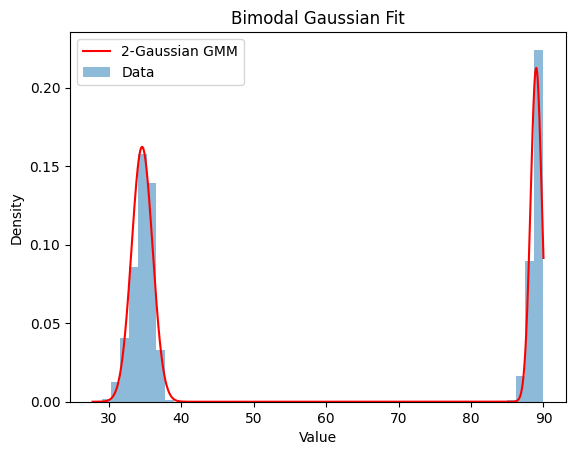

Means: [34.58575762 88.99535651]
Standard Deviations: [1.4445524  0.77371646]
s43


100%|██████████| 5000/5000 [00:17<00:00, 283.55it/s]


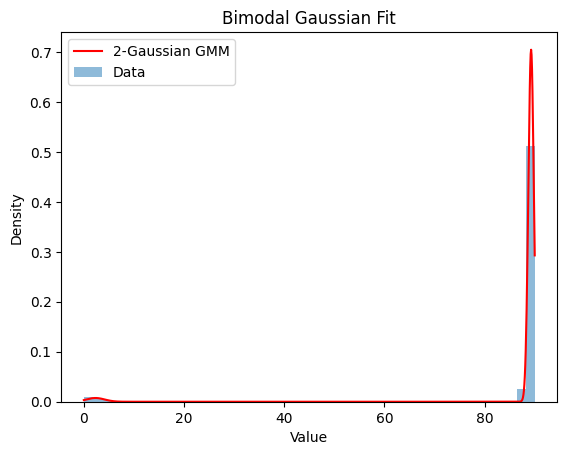

Means: [89.27488073  2.35831128]
Standard Deviations: [0.54712092 1.81620959]


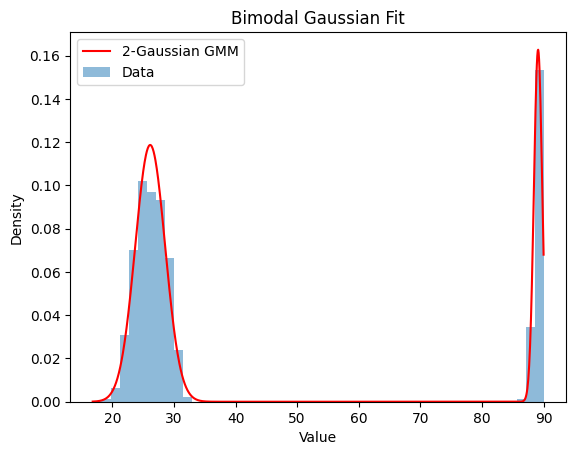

Means: [26.13832648 89.10229743]
Standard Deviations: [2.42884686 0.67876579]


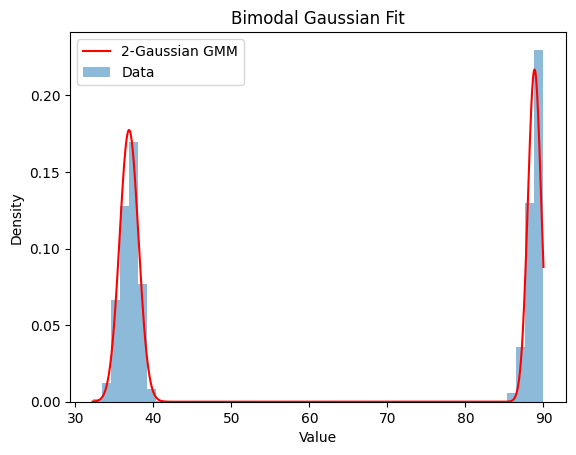

Means: [36.88880861 88.85420956]
Standard Deviations: [1.20584091 0.85254022]


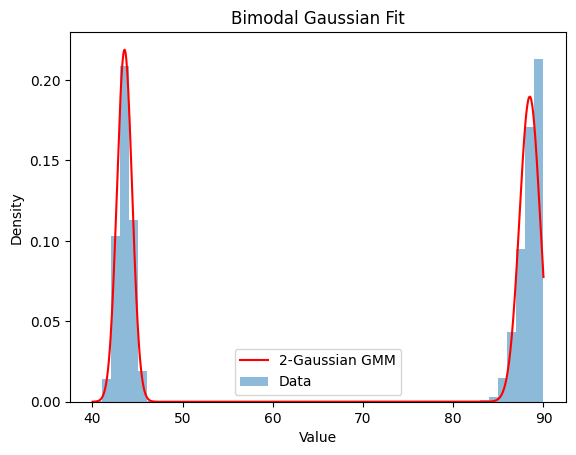

Means: [43.56561401 88.47913322]
Standard Deviations: [0.83757827 1.13682777]
s44


100%|██████████| 5000/5000 [00:17<00:00, 281.41it/s]


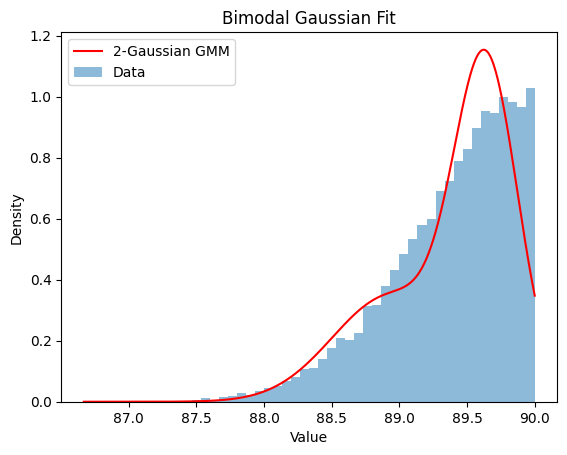

Means: [89.64201328 88.93885677]
Standard Deviations: [0.23465716 0.43420009]


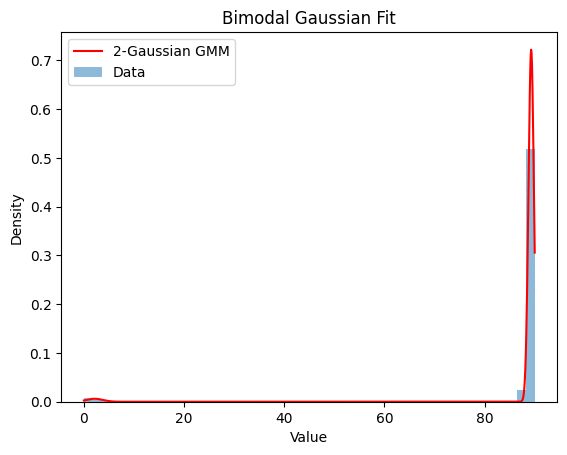

Means: [89.29368385  2.17286569]
Standard Deviations: [0.53881822 1.65068449]


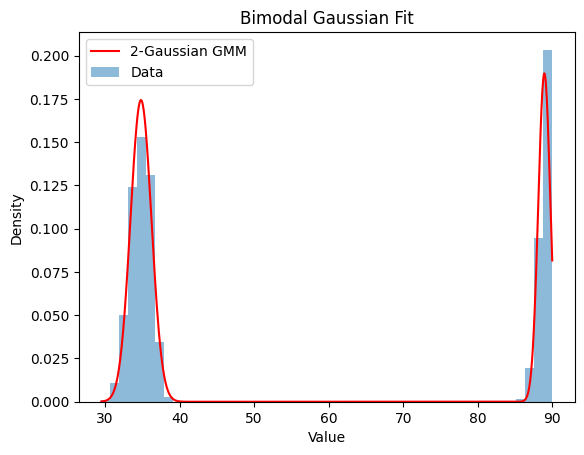

Means: [34.8102471  88.94357084]
Standard Deviations: [1.40444556 0.81233157]


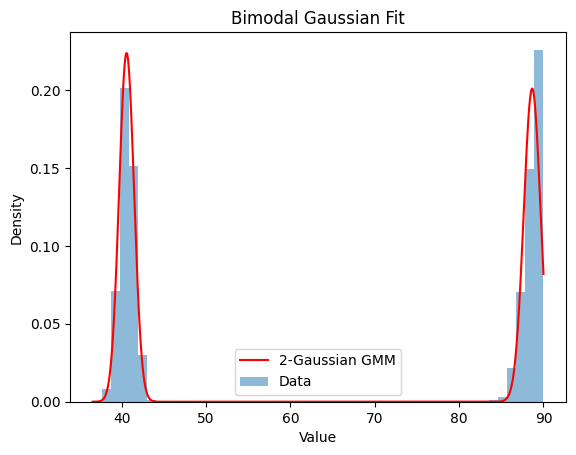

Means: [40.56438953 88.65878565]
Standard Deviations: [0.88426788 1.00146998]


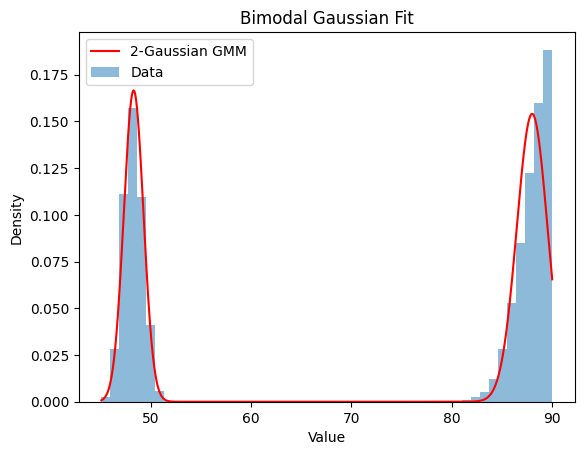

Means: [48.30923971 87.99896205]
Standard Deviations: [0.98060692 1.52987476]


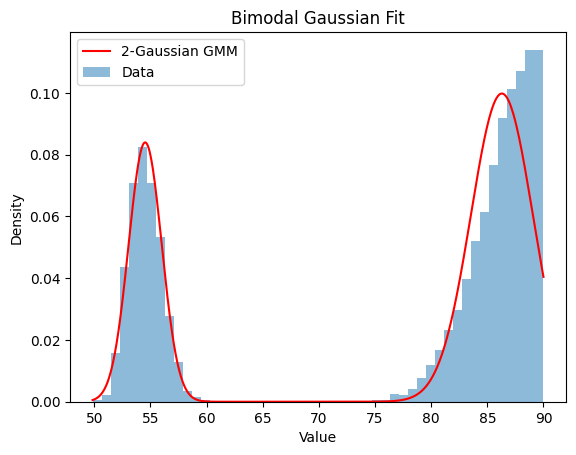

Means: [86.2933929  54.52757523]
Standard Deviations: [2.75703658 1.47409871]


In [9]:
print("s42")
all_lat42, all_stdev42 = runanalysis(u42_peak_frequencies_dt[u42_peak_frequencies_dt>uranus_min_freq], sromovsky2012_odd, frequency_wind_speed(25559000, 17.247864))
print("s43")

all_lat43, all_stdev43 = runanalysis(u43_peak_frequencies_dt[u43_peak_frequencies_dt>uranus_min_freq], sromovsky2012_odd, frequency_wind_speed(25559000, 17.247864))
print("s44")

all_lat44, all_stdev44 = runanalysis(u44_peak_frequencies_dt[u44_peak_frequencies_dt>uranus_min_freq], sromovsky2012_odd, frequency_wind_speed(25559000, 17.247864))

s42


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:21<00:00, 231.10it/s]


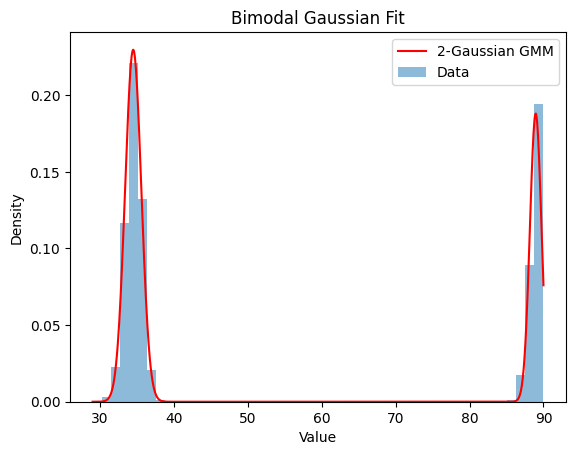

Means: [88.94747937 34.50884468]
Standard Deviations: [0.78178847 1.09688959]
s43


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:18<00:00, 267.39it/s]


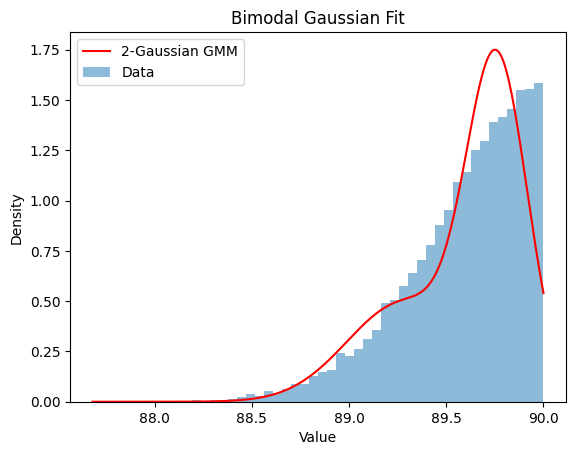

Means: [89.76222312 89.28332319]
Standard Deviations: [0.15721161 0.2940532 ]


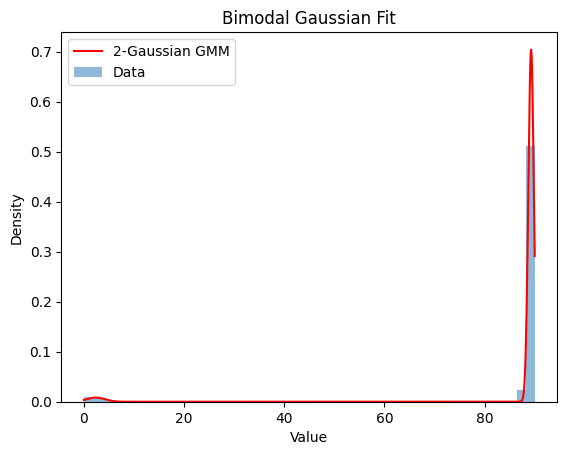

Means: [89.27515922  2.39883629]
Standard Deviations: [0.54557016 1.79648869]


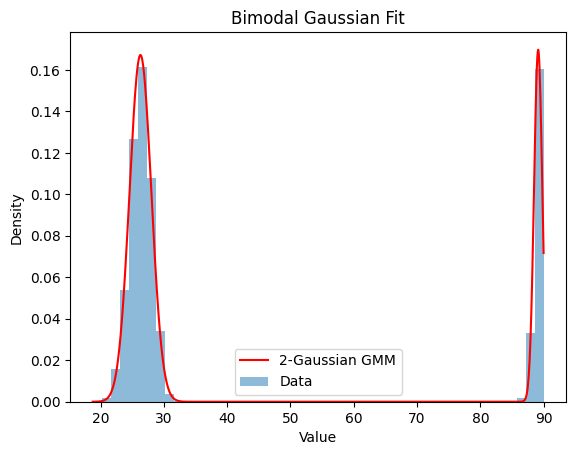

Means: [89.14144663 26.28847   ]
Standard Deviations: [0.65402757 1.7225156 ]


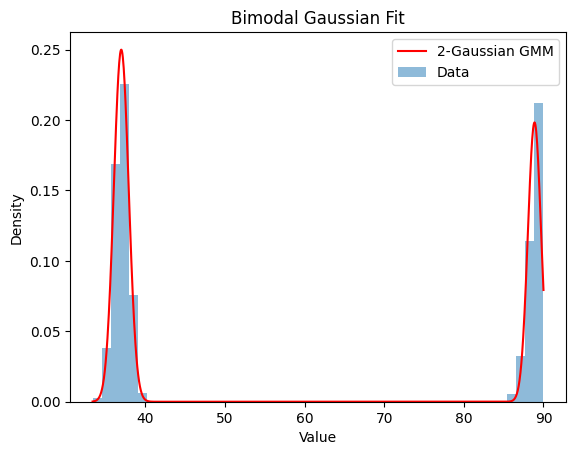

Means: [36.99117882 88.87489837]
Standard Deviations: [0.93650533 0.83062199]


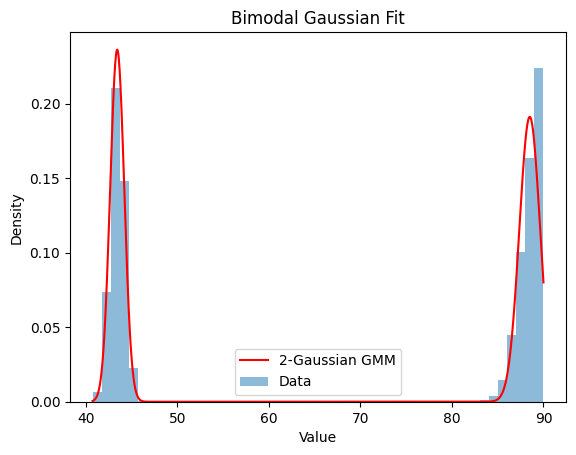

Means: [88.5016479  43.44117255]
Standard Deviations: [1.13579045 0.76886092]
s44


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:18<00:00, 264.43it/s]


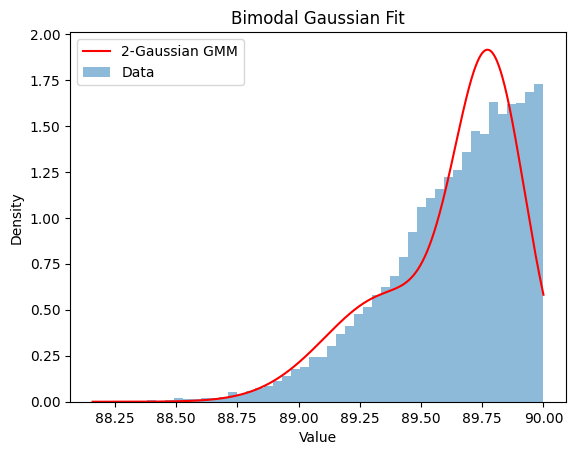

Means: [89.36674512 89.78326724]
Standard Deviations: [0.25976512 0.14270854]


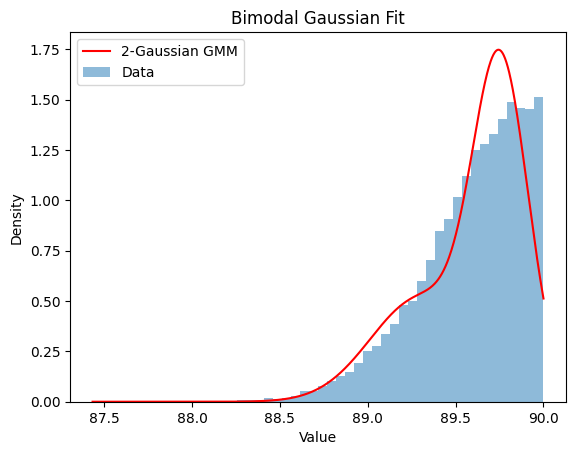

Means: [89.29963967 89.7566866 ]
Standard Deviations: [0.28561907 0.15770144]


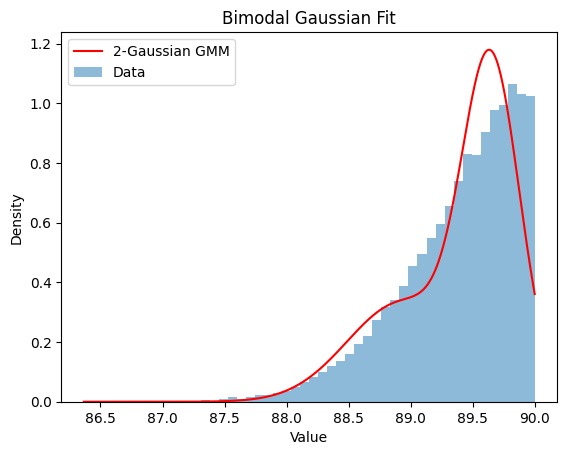

Means: [88.93504166 89.64905052]
Standard Deviations: [0.44755208 0.23081729]


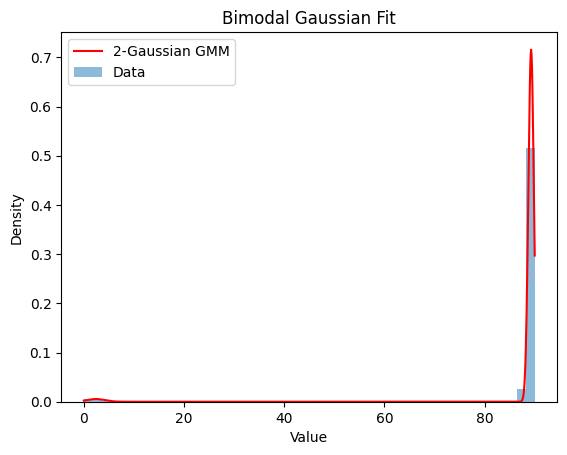

Means: [89.27909436  2.41317881]
Standard Deviations: [0.54370502 1.80182379]


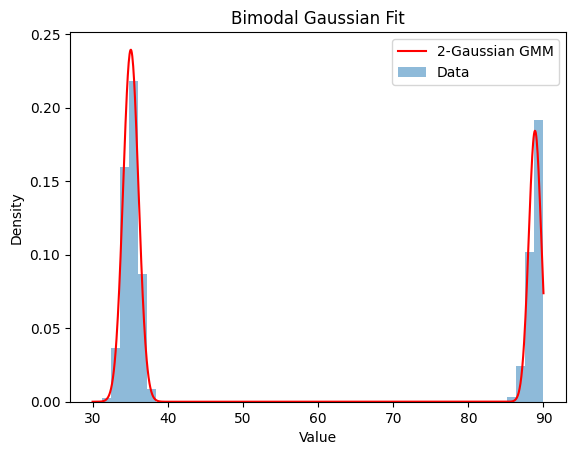

Means: [35.08190677 88.87199691]
Standard Deviations: [1.02435018 0.83352754]


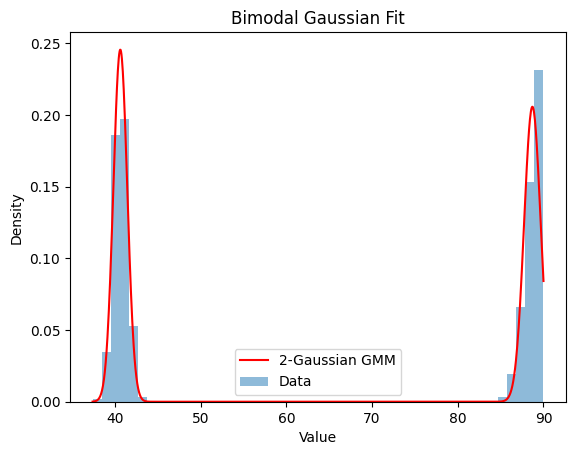

Means: [88.70610384 40.61303143]
Standard Deviations: [0.96746851 0.81366993]


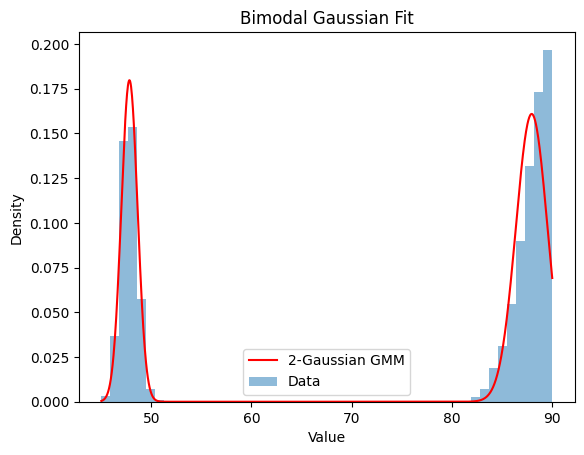

Means: [47.82792564 87.94969593]
Standard Deviations: [0.80635403 1.57785851]


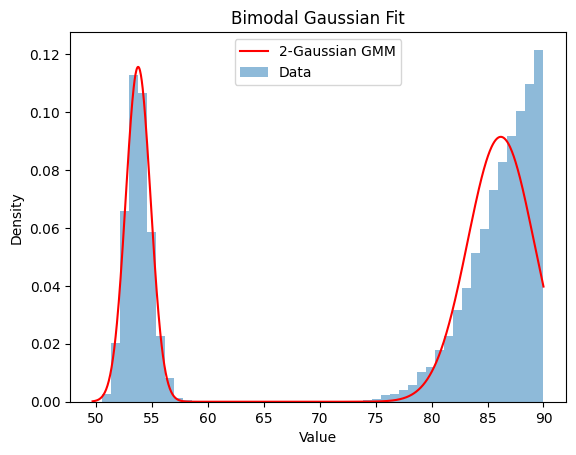

Means: [86.18307189 53.77160014]
Standard Deviations: [2.95651477 1.11277737]


In [25]:
print("s42")
all_lat42, all_stdev42 = runanalysis(u42_peak_frequencies_dt[8:], sromovsky2012_even, frequency_wind_speed)
print("s43")

all_lat43, all_stdev43 = runanalysis(u43_peak_frequencies_dt[12:], sromovsky2012_even, frequency_wind_speed)
print("s44")

all_lat44, all_stdev44 = runanalysis(u44_peak_frequencies_dt[14:], sromovsky2012_even, frequency_wind_speed)

In [25]:
def get_periods(freq_array):
    periods = []
    for freq in freq_array:
        periods.append(24/freq)

    return periods 
    
#print(get_periods(n42_peaks), get_periods(n70_peaks))

In [30]:
lat1 = np.array(latitudes)[:, 0]
lat_list = [float(lat) for lat in standard_devs]

print(lat_list)

# uranus_lats = [30.64502086, 23.36370428, 33.54414927, 42.33367068, 31.32587384, 38.22875582, 49.17756524, 58.54008303]
# values = hammel_wind_speed(np.radians(uranus_lats))
# print('\n'.join(str(v) for v in values))

[0.0061357095248774016, 0.0067437940904371335, 0.007146711837341397, 0.007165186315885295, 0.008343238483533813, 0.00826423218244495, 0.008865926055415517, 0.009396417899396265, 0.009627706388571074, 0.01221857370591848, 0.014064065028629018, 2.6714659621242234, 2.128164803825939, 1.384354165099579, 0.9564253242359686, 0.8574705312643042, 0.25080054525869305, 0.21783881146047443]


/tmp/ipykernel_1332915/2446407363.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lat_list = [float(lat) for lat in standard_devs]


In [32]:
u42_lat = [40.37513393]
u43_lat = [51.63244486, 42.96252028, 34.27850805, 21.29449409]
u44_lat = [71.48033179, 59.13319823, 47.49386962, 40.95031544, 31.86512009, 20.89460628]

u42_wind = hammel_wind_speed(np.radians(u42_lat))
u43_wind = hammel_wind_speed(np.radians(u43_lat))
u44_wind = hammel_wind_speed(np.radians(u44_lat))

print(u42_wind, u43_wind, u44_wind)

[165.58078363] [217.25513859 181.3685605  122.04960134  20.20239801] [172.59881634 222.15542901 203.75508932 169.25579683 103.20330144
  17.27919731]
